## 1. Import libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 2. Loading data

In [5]:
xls = pd.ExcelFile('../data/raw/Employee Performance Dataset.xlsx')

employees = pd.read_excel(xls, sheet_name= 'employees')
stores = pd.read_excel(xls, sheet_name='stores')
monthly_performance = pd.read_excel(xls, sheet_name='monthly_performance')
role_kpis = pd.read_excel(xls, sheet_name= 'role_kpis')
business = pd.read_excel(xls, sheet_name= 'business_outcomes')

## 3. Data understanding

In [6]:
print("Employees:", employees.shape)
print("Stores:", stores.shape)
print("Monthly performance:", monthly_performance.shape)
print("Role KPIs:", role_kpis.shape)
print("Business outcomes:", business.shape)

Employees: (7500, 18)
Stores: (150, 7)
Monthly performance: (236591, 13)
Role KPIs: (236591, 9)
Business outcomes: (16200, 9)


### 3.1 Employees

In [7]:
employees.head()

,Employee_Id,Full_Name,Age,Education_Level,Hire_Date,Exit_Date,Department,Job_Role,Job_Level,Employment_Type,Base_Salary_Annual,Store_Location,Store_Location_Latitude,Store_Location_Longitude,Store_Id,Manager_Id,Manager_Name,Manager_Status
0,EMP000001,Marie Kim DDS,23,Master's,26/04/2021,13/04/2022,Store Operations,Cashier,Entry,Full-time,25745.40,Charlotte,35.2271,-80.8431,STR058,EMP001131,Michelle Walls,Executive
1,EMP000002,Danny Morgan,26,Master's,03/09/2021,NaN,Store Operations,Sales Associate,Associate,Full-time,39408.57,San Jose,37.3382,-121.8863,STR137,EMP002456,Jennifer Moore,Executive
2,EMP000003,Crystal Robinson,38,Bachelor's,25/08/2016,NaN,Store Operations,Cashier,Entry,Full-time,29319.94,Jacksonville,30.3322,-81.6557,STR008,EMP000529,Melissa Bishop,Senior Manager
3,EMP000004,Mark Perez,33,Bachelor's,10/12/2021,NaN,Store Operations,Senior Sales Associate,Senior_Associate,Full-time,43979.88,Las Vegas,36.1699,-115.1398,STR063,EMP001305,Tina Walter,Senior Manager
4,EMP000005,Shannon Jones,24,High School,24/02/2018,NaN,Store Operations,Cashier,Entry,Full-time,23560.19,Chicago,41.8781,-87.6298,STR109,EMP001823,Nicholas Fitzgerald,Senior Manager


In [8]:
employees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Employee_Id               7500 non-null   object 
 1   Full_Name                 7500 non-null   object 
 2   Age                       7500 non-null   int64  
 3   Education_Level           7500 non-null   object 
 4   Hire_Date                 7500 non-null   object 
 5   Exit_Date                 1491 non-null   object 
 6   Department                7500 non-null   object 
 7   Job_Role                  7500 non-null   object 
 8   Job_Level                 7500 non-null   object 
 9   Employment_Type           7500 non-null   object 
 10  Base_Salary_Annual        7500 non-null   float64
 11  Store_Location            7500 non-null   object 
 12  Store_Location_Latitude   7500 non-null   float64
 13  Store_Location_Longitude  7500 non-null   float64
 14  Store_Id

In [9]:
employees.isna().sum()

Employee_Id                    0
Full_Name                      0
Age                            0
Education_Level                0
Hire_Date                      0
Exit_Date                   6009
Department                     0
Job_Role                       0
Job_Level                      0
Employment_Type                0
Base_Salary_Annual             0
Store_Location                 0
Store_Location_Latitude        0
Store_Location_Longitude       0
Store_Id                       0
Manager_Id                     5
Manager_Name                   5
Manager_Status                 5
dtype: int64

### 3.2 Stores

In [10]:
stores.head()

,Store_Id,Store_Name,City,City_Latitude,City_Longitude,Store_Type,Opening_Date
0,STR001,San Antonio Regular #1,San Antonio,29.4241,-98.4936,Regular,20/05/2021
1,STR002,Charlotte Regular #2,Charlotte,35.2271,-80.8431,Regular,09/11/2015
2,STR003,Portland Superstore #3,Portland,45.5152,-122.6784,Superstore,08/02/2018
3,STR004,Nashville Superstore #4,Nashville,36.1627,-86.7816,Superstore,21/08/2017
4,STR005,Austin Regular #5,Austin,30.2672,-97.7431,Regular,04/04/2022


In [11]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Store_Id        150 non-null    object 
 1   Store_Name      150 non-null    object 
 2   City            150 non-null    object 
 3   City_Latitude   150 non-null    float64
 4   City_Longitude  150 non-null    float64
 5   Store_Type      150 non-null    object 
 6   Opening_Date    150 non-null    object 
dtypes: float64(2), object(5)
memory usage: 8.3+ KB


In [12]:
stores.isna().sum()

Store_Id          0
Store_Name        0
City              0
City_Latitude     0
City_Longitude    0
Store_Type        0
Opening_Date      0
dtype: int64

### 3.3 Monthly Performance

In [13]:
monthly_performance.head()

,Employee_Id,Year_Month,Performance_Rating,Training_Hours,Overtime_Hours,Absenteeism_Days,Promotion_Flag,Salary_Increase_Flag,Monthly_Bonus,Benefits_Cost,Employee_Satisfaction,Engagement_Index,Manager_Evaluation
0,EMP000001,2022-01,4.13,2,15,1,False,False,657.44,1727.09,8.0,8.1,4.5
1,EMP000002,2022-01,3.60,9,10,1,False,False,626.76,1584.89,8.0,9.1,3.6
2,EMP000003,2022-01,3.65,3,12,0,False,False,554.12,1584.56,6.3,5.1,3.5
3,EMP000004,2022-01,3.51,6,8,0,False,False,669.14,1759.48,8.1,8.0,3.3
4,EMP000005,2022-01,5.00,1,4,1,False,False,235.22,947.89,10.0,9.7,5.0


In [14]:
monthly_performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236591 entries, 0 to 236590
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Employee_Id            236591 non-null  object 
 1   Year_Month             236591 non-null  object 
 2   Performance_Rating     236591 non-null  float64
 3   Training_Hours         236591 non-null  int64  
 4   Overtime_Hours         236591 non-null  int64  
 5   Absenteeism_Days       236591 non-null  int64  
 6   Promotion_Flag         236591 non-null  bool   
 7   Salary_Increase_Flag   236591 non-null  bool   
 8   Monthly_Bonus          236591 non-null  float64
 9   Benefits_Cost          236591 non-null  float64
 10  Employee_Satisfaction  236591 non-null  float64
 11  Engagement_Index       236591 non-null  float64
 12  Manager_Evaluation     236591 non-null  float64
dtypes: bool(2), float64(6), int64(3), object(2)
memory usage: 20.3+ MB


In [15]:
monthly_performance.isna().sum()

Employee_Id              0
Year_Month               0
Performance_Rating       0
Training_Hours           0
Overtime_Hours           0
Absenteeism_Days         0
Promotion_Flag           0
Salary_Increase_Flag     0
Monthly_Bonus            0
Benefits_Cost            0
Employee_Satisfaction    0
Engagement_Index         0
Manager_Evaluation       0
dtype: int64

### 3.4 Role KPIs

In [16]:
role_kpis.head()

,Employee_Id,Year_Month,Kpi_1_Value,Kpi_1_Name,Kpi_2_Value,Kpi_2_Name,Kpi_3_Value,Kpi_3_Name,Productivity_Index
0,EMP000001,2022-01,87.77,Task Completion Rate %,8.20,Quality Score,9.15,Efficiency Rating,1.565
1,EMP000002,2022-01,88.94,Task Completion Rate %,6.66,Quality Score,6.09,Efficiency Rating,1.302
2,EMP000003,2022-01,85.00,Store Sales vs Target %,17.37,Employee Turnover %,7.21,Customer Satisfaction,1.323
3,EMP000004,2022-01,88.51,Store Sales vs Target %,7.98,Employee Turnover %,8.60,Customer Satisfaction,1.253
4,EMP000005,2022-01,100.00,Task Completion Rate %,8.26,Quality Score,8.82,Efficiency Rating,2.000


In [17]:
role_kpis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236591 entries, 0 to 236590
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Employee_Id         236591 non-null  object 
 1   Year_Month          236591 non-null  object 
 2   Kpi_1_Value         236591 non-null  float64
 3   Kpi_1_Name          236591 non-null  object 
 4   Kpi_2_Value         236591 non-null  float64
 5   Kpi_2_Name          236591 non-null  object 
 6   Kpi_3_Value         236591 non-null  float64
 7   Kpi_3_Name          236591 non-null  object 
 8   Productivity_Index  236591 non-null  float64
dtypes: float64(4), object(5)
memory usage: 16.2+ MB


In [18]:
role_kpis.isna().sum()

Employee_Id           0
Year_Month            0
Kpi_1_Value           0
Kpi_1_Name            0
Kpi_2_Value           0
Kpi_2_Name            0
Kpi_3_Value           0
Kpi_3_Name            0
Productivity_Index    0
dtype: int64

### 3.5 Business Outcome

In [19]:
business.head()

,Store_Id,Department,Year_Month,Sales_Target,Sales_Actual,Customer_Satisfaction,Nps_Score,Waste_Percentage,On_Time_Delivery
0,STR001,Store Operations,2022-01,153000,164399.59,7.4,47.0,0.73,98.6
1,STR001,Fresh Produce,2022-01,38250,39851.00,8.5,51.5,2.73,92.4
2,STR001,Meat/Fish & Bakery,2022-01,29750,30829.76,5.6,-24.1,3.64,92.3
3,STR002,Store Operations,2022-01,153000,143176.34,6.8,14.6,1.68,87.6
4,STR002,Fresh Produce,2022-01,38250,38637.44,6.1,3.3,4.43,94.3


In [20]:
business.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16200 entries, 0 to 16199
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Store_Id               16200 non-null  object 
 1   Department             16200 non-null  object 
 2   Year_Month             16200 non-null  object 
 3   Sales_Target           16200 non-null  int64  
 4   Sales_Actual           16200 non-null  float64
 5   Customer_Satisfaction  16200 non-null  float64
 6   Nps_Score              16200 non-null  float64
 7   Waste_Percentage       16200 non-null  float64
 8   On_Time_Delivery       16200 non-null  float64
dtypes: float64(5), int64(1), object(3)
memory usage: 1.1+ MB


In [21]:
business.isna().sum()

Store_Id                 0
Department               0
Year_Month               0
Sales_Target             0
Sales_Actual             0
Customer_Satisfaction    0
Nps_Score                0
Waste_Percentage         0
On_Time_Delivery         0
dtype: int64

#### Missing Value Analysis

The dataset contains a limited number of missing values, which are primarily concentrated in specific fields.

#### Key Observations

- The `Exit_Date` column contains a large number of missing values (6009 records).  
  This is expected and represents employees who are still active in the company.

- A small number of missing values (5 records) are found in:
  - `Manager_Id`
  - `Manager_Name`
  - `Manager_Status`

  These likely correspond to top-level roles (e.g., executives) or minor data inconsistencies.

#### Data Quality Assessment

Overall, the dataset demonstrates strong data quality, with missing values being minimal and logically explainable.

No major data cleaning or imputation is required at this stage.

## 4. Data cleaning

In [22]:
# Date Standardization
employees["Hire_Date"] = pd.to_datetime(employees["Hire_Date"], errors="coerce")
employees["Exit_Date"] = pd.to_datetime(employees["Exit_Date"], errors="coerce")

monthly_performance["Year_Month"] = pd.to_datetime(monthly_performance["Year_Month"], errors="coerce")
role_kpis["Year_Month"] = pd.to_datetime(role_kpis["Year_Month"], errors="coerce")
business["Year_Month"] = pd.to_datetime(business["Year_Month"], errors="coerce")

stores["Opening_Date"] = pd.to_datetime(stores["Opening_Date"], errors="coerce")

C:\Users\user\AppData\Local\Temp\ipykernel_22808\4222565498.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  employees["Hire_Date"] = pd.to_datetime(employees["Hire_Date"], errors="coerce")
C:\Users\user\AppData\Local\Temp\ipykernel_22808\4222565498.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  employees["Exit_Date"] = pd.to_datetime(employees["Exit_Date"], errors="coerce")
C:\Users\user\AppData\Local\Temp\ipykernel_22808\4222565498.py:9: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  stores["Opening_Date"] = pd.to_datetime(stores["Opening_Date"], errors="coerce")


### Add column Attrition

In [23]:
employees["Is_Exited"] = employees["Exit_Date"].notna().astype(int)
employees.head()

,Employee_Id,Full_Name,Age,Education_Level,Hire_Date,Exit_Date,Department,Job_Role,Job_Level,Employment_Type,Base_Salary_Annual,Store_Location,Store_Location_Latitude,Store_Location_Longitude,Store_Id,Manager_Id,Manager_Name,Manager_Status,Is_Exited
0,EMP000001,Marie Kim DDS,23,Master's,2021-04-26,2022-04-13,Store Operations,Cashier,Entry,Full-time,25745.40,Charlotte,35.2271,-80.8431,STR058,EMP001131,Michelle Walls,Executive,1
1,EMP000002,Danny Morgan,26,Master's,2021-09-03,NaT,Store Operations,Sales Associate,Associate,Full-time,39408.57,San Jose,37.3382,-121.8863,STR137,EMP002456,Jennifer Moore,Executive,0
2,EMP000003,Crystal Robinson,38,Bachelor's,2016-08-25,NaT,Store Operations,Cashier,Entry,Full-time,29319.94,Jacksonville,30.3322,-81.6557,STR008,EMP000529,Melissa Bishop,Senior Manager,0
3,EMP000004,Mark Perez,33,Bachelor's,2021-12-10,NaT,Store Operations,Senior Sales Associate,Senior_Associate,Full-time,43979.88,Las Vegas,36.1699,-115.1398,STR063,EMP001305,Tina Walter,Senior Manager,0
4,EMP000005,Shannon Jones,24,High School,2018-02-24,NaT,Store Operations,Cashier,Entry,Full-time,23560.19,Chicago,41.8781,-87.6298,STR109,EMP001823,Nicholas Fitzgerald,Senior Manager,0


## 5. Data Preparation
In this section, the datasets are merged and validated to create analysis-ready tables for employee-level and store-level analytics.

In [22]:
# Merge employee monthly data
employee_monthly_df = (
    monthly_performance.merge(
        employees,
        on="Employee_Id",
        how="left"
    ).merge(
        role_kpis,
        on=["Employee_Id", "Year_Month"],
        how="left"
    ).merge(
        stores,
        on="Store_Id",
        how="left"
    )
)

employee_monthly_df.to_parquet(
    "../data/processed/employee_monthly.parquet",
    index=False
)
print("Saved dataset to data/processed/employee_monthly.parquet")

Saved dataset to data/processed/employee_monthly.parquet


In [24]:
employee_monthly_df = pd.read_parquet("../data/processed/employee_monthly.parquet")
employee_monthly_df.head()

,Employee_Id,Year_Month,Performance_Rating,Training_Hours,Overtime_Hours,Absenteeism_Days,Promotion_Flag,Salary_Increase_Flag,Monthly_Bonus,Benefits_Cost,...,Kpi_2_Name,Kpi_3_Value,Kpi_3_Name,Productivity_Index,Store_Name,City,City_Latitude,City_Longitude,Store_Type,Opening_Date
0,EMP000001,2022-01-01,4.13,2,15,1,False,False,657.44,1727.09,...,Quality Score,9.15,Efficiency Rating,1.565,Detroit Regular #58,Detroit,42.3314,-83.0458,Regular,2022-03-11
1,EMP000002,2022-01-01,3.60,9,10,1,False,False,626.76,1584.89,...,Quality Score,6.09,Efficiency Rating,1.302,Nashville Regular #137,Nashville,36.1627,-86.7816,Regular,2016-04-02
2,EMP000003,2022-01-01,3.65,3,12,0,False,False,554.12,1584.56,...,Employee Turnover %,7.21,Customer Satisfaction,1.323,Los Angeles Regular #8,Los Angeles,34.0522,-118.2437,Regular,2016-05-30
3,EMP000004,2022-01-01,3.51,6,8,0,False,False,669.14,1759.48,...,Employee Turnover %,8.60,Customer Satisfaction,1.253,San Antonio Regular #63,San Antonio,29.4241,-98.4936,Regular,2020-08-22
4,EMP000005,2022-01-01,5.00,1,4,1,False,False,235.22,947.89,...,Quality Score,8.82,Efficiency Rating,2.000,Boston Regular #109,Boston,42.3601,-71.0589,Regular,2019-09-18


In [25]:
print("Original monthly rows:", monthly_performance.shape[0])
print("Final df rows:", employee_monthly_df .shape[0])

Original monthly rows: 236591
Final df rows: 236591


In [34]:
employee_monthly_df .isnull().sum().sort_values(ascending=False)

Exit_Date                   216324
Manager_Id                     180
Manager_Name                   180
Manager_Status                 180
Employee_Id                      0
Store_Location                   0
Store_Location_Longitude         0
Store_Id                         0
Is_Exited                        0
Kpi_1_Value                      0
Kpi_1_Name                       0
Kpi_2_Value                      0
Kpi_2_Name                       0
Kpi_3_Value                      0
Kpi_3_Name                       0
Productivity_Index               0
Store_Name                       0
City                             0
City_Latitude                    0
City_Longitude                   0
Store_Type                       0
Store_Location_Latitude          0
Base_Salary_Annual               0
Year_Month                       0
Employee_Satisfaction            0
Performance_Rating               0
Training_Hours                   0
Overtime_Hours                   0
Absenteeism_Days    

In [27]:
employee_monthly_df[["Employee_Id", "Year_Month"]].duplicated().sum()

0

## 6. Data Quality Checks

In [28]:
numeric_columns = [
    "Age",
    "Base_Salary_Annual",
    "Performance_Rating",
    "Training_Hours",
    "Overtime_Hours",
    "Absenteeism_Days",
    "Employee_Satisfaction",
    "Engagement_Index",
    "Manager_Evaluation",
    "Productivity_Index"
]

employee_monthly_df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,236591.0,32.372791,7.480891,21.00,26.000,32.000,37.000,64.00
Base_Salary_Annual,236591.0,27747.198715,10129.761311,8823.46,21891.020,27884.310,32255.470,177873.61
Performance_Rating,236591.0,3.701753,0.442421,1.00,3.400,3.720,4.020,5.00
Training_Hours,236591.0,2.807681,2.273293,0.00,1.000,2.000,4.000,27.00
Overtime_Hours,236591.0,8.031658,4.981170,0.00,4.000,8.000,11.000,39.00
Absenteeism_Days,236591.0,0.711637,0.861559,0.00,0.000,1.000,1.000,7.00
Employee_Satisfaction,236591.0,7.238340,1.292169,1.00,6.400,7.200,8.100,10.00
Engagement_Index,236591.0,7.220323,1.485795,1.00,6.200,7.200,8.300,10.00
Manager_Evaluation,236591.0,3.700053,0.533884,1.00,3.300,3.700,4.100,5.00
Productivity_Index,236591.0,1.350878,0.221203,0.00,1.202,1.361,1.509,2.00


In [29]:
invalid_salary = employee_monthly_df[employee_monthly_df["Base_Salary_Annual"] < 0]
invalid_performance = employee_monthly_df[
    (employee_monthly_df["Performance_Rating"] < 0) |
    (employee_monthly_df["Performance_Rating"] > 5)
]

print("Invalid salary records:", invalid_salary.shape[0])
print("Invalid performance records:", invalid_performance.shape[0])

Invalid salary records: 0
Invalid performance records: 0


## Business Analysis
### Q1: Attrition Analysis
In this section, we calculate the total number of employees who have exited the company and the departments with the highest attrition rates.   
Attrition rate is the percentage of employees who have left the company relative to the total number of employees.

In [51]:
# Calculate total attrition (total number of employees who exited)
total_employees = employees['Employee_Id'].nunique()
total_exited = employees['Is_Exited'].sum()
attrition_rate = total_exited / total_employees * 100

print(f'Total employees: {total_employees}')
print(f'Total exited employees: {total_exited}')
print(f'Overall attrition rate: {round(attrition_rate, 2)}%')

#  Calculate attrition by department 
attrition_by_department = (
    employees.groupby('Department', as_index= False)
    .agg(
        Total_Employees=('Employee_Id', 'nunique'),
        Total_Exited=('Is_Exited', 'sum'),
    )
)

attrition_by_department['Attrition_Rate'] = (
    attrition_by_department['Total_Exited'] / 
    attrition_by_department['Total_Employees']
) * 100

attrition_by_department = attrition_by_department.sort_values(
    'Attrition_Rate',
    ascending= False
).reset_index(drop= True)

attrition_by_department.round(2)

Total employees: 7500
Total exited employees: 1491
Overall attrition rate: 19.88%


,Department,Total_Employees,Total_Exited,Attrition_Rate
0,HR,225,50,22.22
1,Logistics/Warehousing,1500,333,22.20
2,Marketing,150,31,20.67
3,Fresh Produce,1125,229,20.36
4,Store Operations,3000,568,18.93
5,Meat/Fish & Bakery,900,170,18.89
6,Customer Service,150,28,18.67
7,Finance,225,42,18.67
8,IT,225,40,17.78


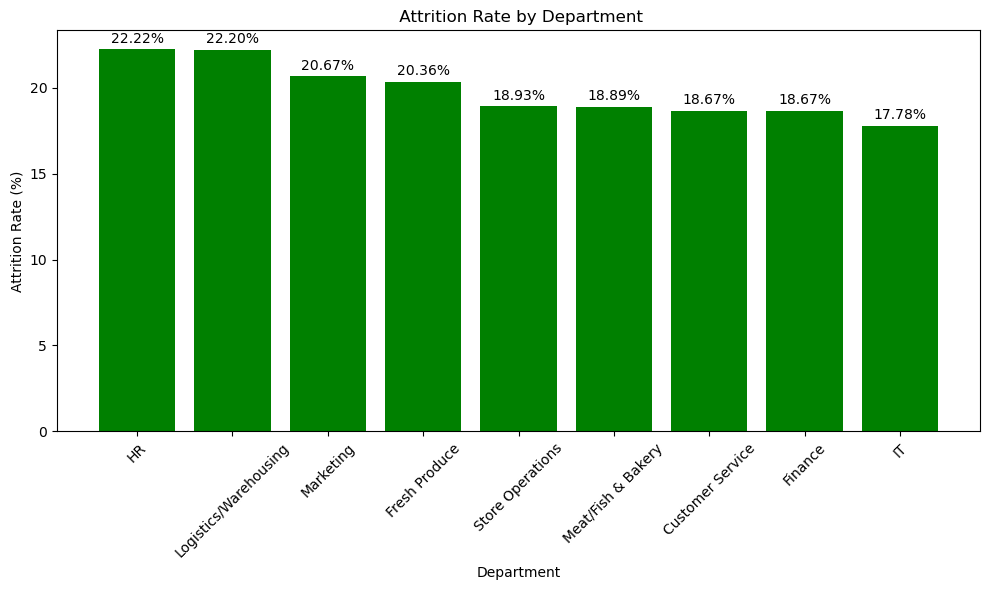

In [ ]:
plt.figure(figsize=(10,6))

bar = plt.bar(
    attrition_by_department['Department'], 
    attrition_by_department['Attrition_Rate'], 
    color = 'green'
    )

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.2,
        f'{height:.2f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title(' Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


### Q2: Salary Analysis
In this section, we calculate what is the average salary by job level, and how does salary compare across departments?  
This analysis evaluates compensation distribution across job levels and departments.

In [60]:
# Calculate salary by job level
salary_by_job_level = (
    employees.groupby('Job_Level', as_index=False)
    .agg(Avg_Salary = ('Base_Salary_Annual', 'mean'))
    .sort_values('Avg_Salary', ascending= False)
)

salary_by_job_level.round(2)


,Job_Level,Avg_Salary
2,Executive,111146.40
5,Senior_Manager,92330.43
3,Manager,65360.10
6,Supervisor,42331.51
4,Senior_Associate,36395.48
0,Associate,29013.14
1,Entry,23051.67


In [61]:
# Calculate salary by department
salary_by_department = (
    employees.groupby('Department', as_index=False)
    .agg(Avg_Salary = ('Base_Salary_Annual', 'mean'))
    .sort_values('Avg_Salary', ascending=False)
)

salary_by_department.round(2)

,Department,Avg_Salary
4,IT,28560.18
1,Finance,28055.53
5,Logistics/Warehousing,27574.70
8,Store Operations,27404.36
2,Fresh Produce,26915.95
6,Marketing,26796.82
3,HR,26539.92
7,Meat/Fish & Bakery,26535.72
0,Customer Service,26244.39


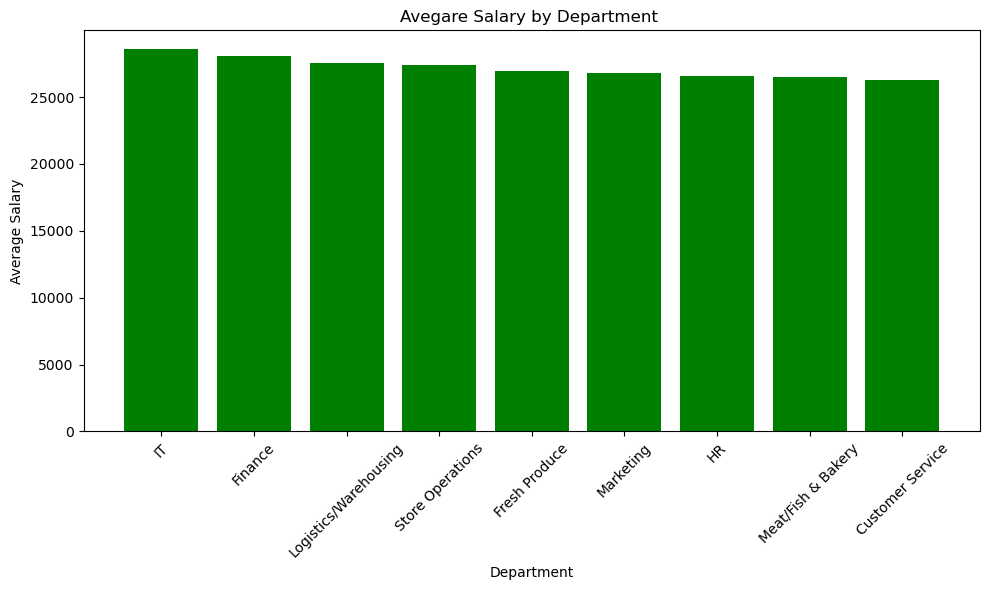

In [67]:
plt.figure(figsize=(10,6))
plt.bar(
    salary_by_department['Department'], 
    salary_by_department['Avg_Salary'], 
    color = 'green')

plt.title('Avegare Salary by Department ')
plt.xlabel('Department')
plt.ylabel('Average Salary')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

## Q3. Performance Trend Analysis
In this section, we analysis:    
Which months show the highest employee performance ratings?  
This analysis identifies the months with the highest average employee performance ratings and helps detect seasonal or operational performance trends over time.